<a href="https://colab.research.google.com/github/JefCabnt/CPE-018---CPE31S2/blob/main/Activity_9_ORB_Feature_Detection_and_Feature_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.** | **TITLE**
**Name** | LastName, FirstName
**Section** | CPE31Sx
**Date Performed**: |
**Date Submitted**: |
**Instructor**: | Dr. Jonathan V. Taylar / Engr. Verlyn V. Nojor / Engr. Roman M. Richard

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [5]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/drive/MyDrive/CPE018/playstation.png', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/drive/MyDrive/CPE018/ps4.jpg', cv2.IMREAD_GRAYSCALE)

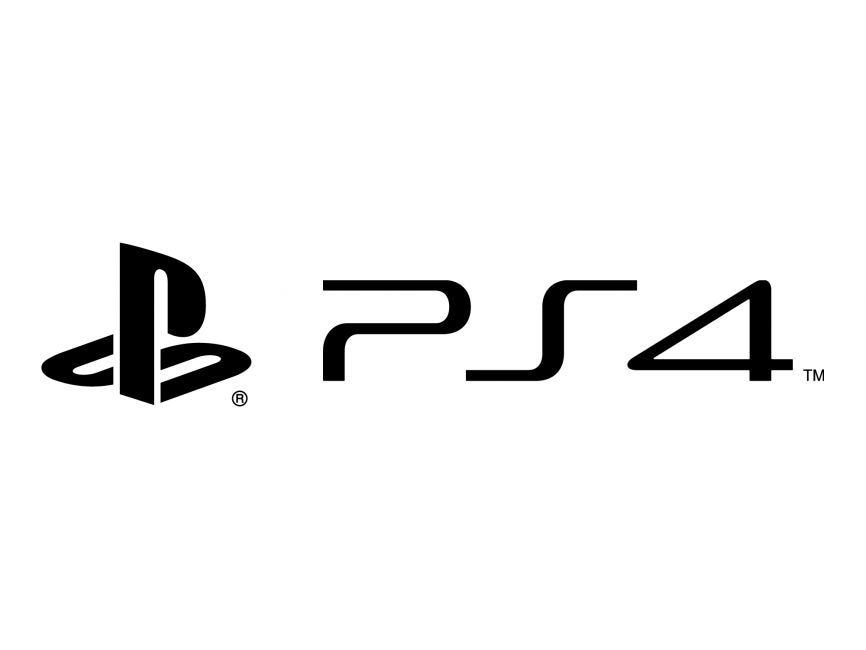

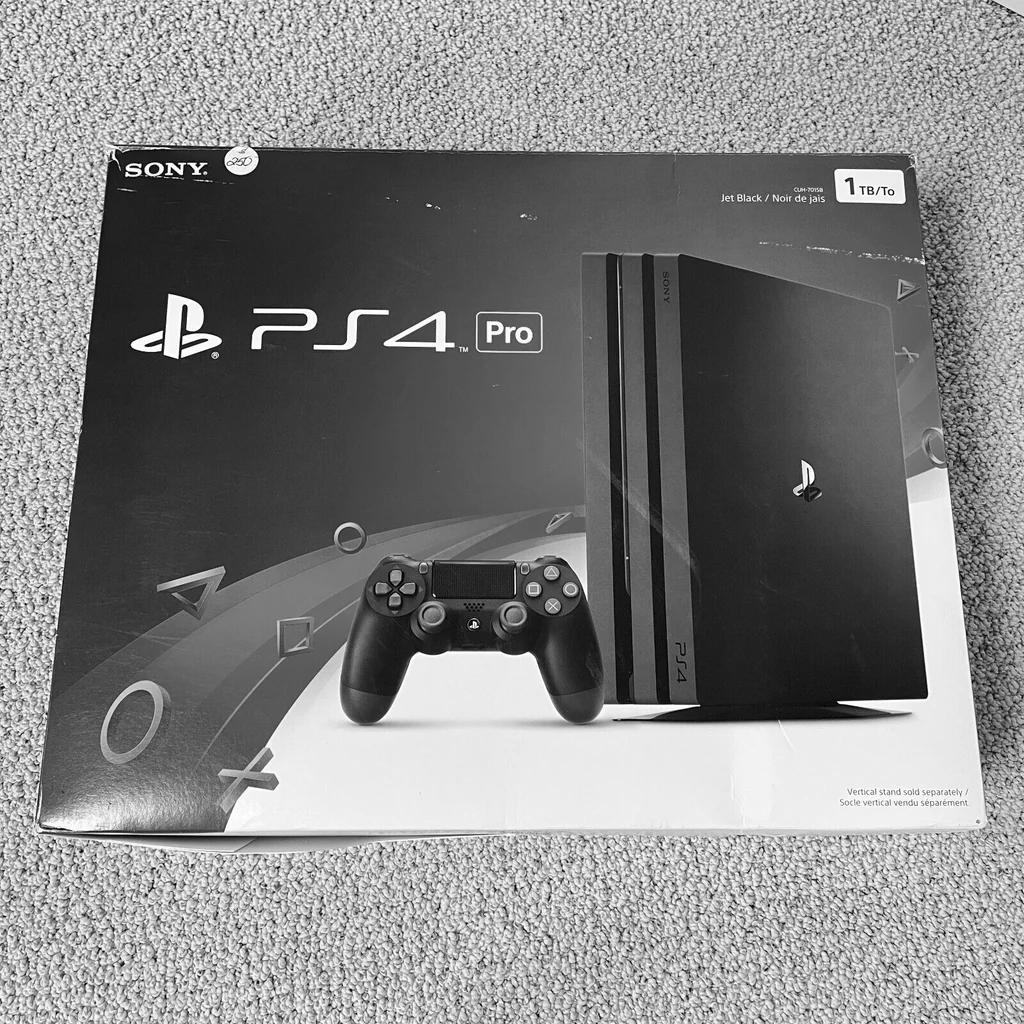

In [6]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of detector and descriptor and why they're used here.**

In [8]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [9]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

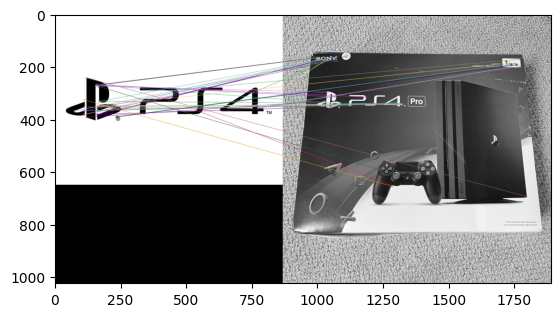

(<matplotlib.image.AxesImage at 0x7e4f04972ba0>, None)

In [10]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?

## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**

Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

Find 2 images of brand logos on the internet.

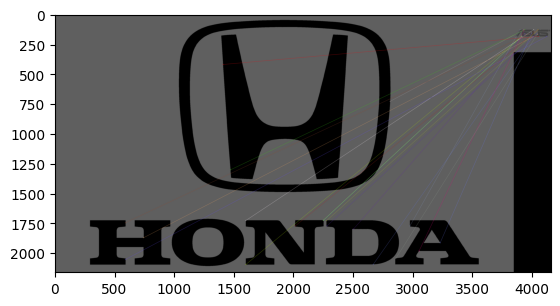

In [13]:
import cv2
import matplotlib.pyplot as plt

logo = cv2.imread('/content/drive/MyDrive/CPE018/honda.png', 0)
product = cv2.imread('/content/drive/MyDrive/CPE018/asus.png', 0)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(logo, None)
kp2, des2 = orb.detectAndCompute(product, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

result = cv2.drawMatches(logo, kp1, product, kp2, matches[:30], None, flags=2)

plt.imshow(result)
plt.show()

Find 5 product images containing one logo each.

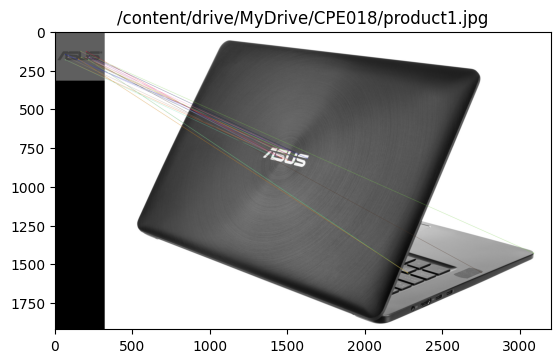

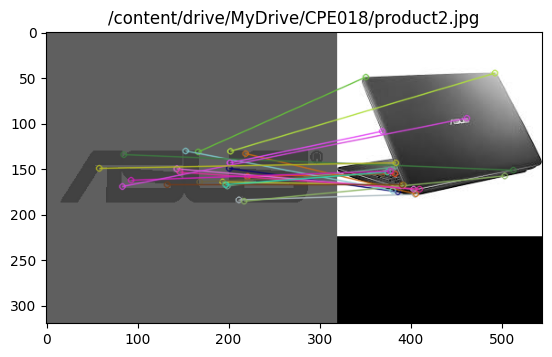

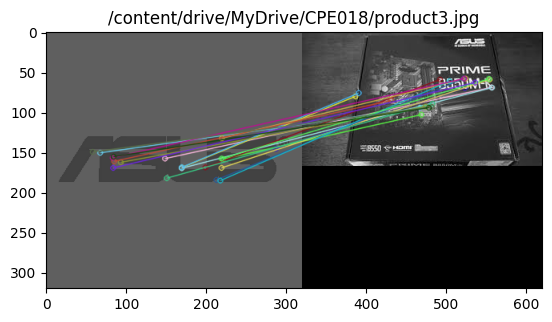

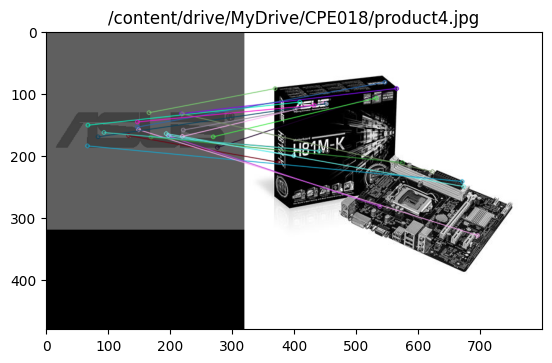

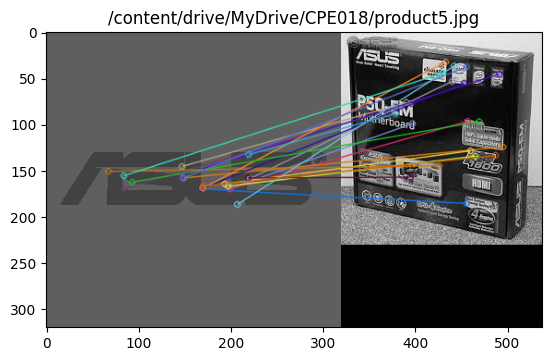

In [18]:
import cv2
import matplotlib.pyplot as plt

logo = cv2.imread('/content/drive/MyDrive/CPE018/asus.png', 0)

product_paths = [
    '/content/drive/MyDrive/CPE018/product1.jpg',
    '/content/drive/MyDrive/CPE018/product2.jpg',
    '/content/drive/MyDrive/CPE018/product3.jpg',
    '/content/drive/MyDrive/CPE018/product4.jpg',
    '/content/drive/MyDrive/CPE018/product5.jpg'
]

orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(logo, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

for path in product_paths:
    product = cv2.imread(path, 0)
    if product is None: # Added error handling
        print(f"Warning: Could not load image from {path}. Skipping.")
        continue
    kp2, des2 = orb.detectAndCompute(product, None)

    # Check if descriptors were computed
    if des1 is None or des2 is None:
        print(f"Warning: Could not compute descriptors for {path}. Skipping.")
        continue

    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    result = cv2.drawMatches(logo, kp1, product, kp2, matches[:20], None, flags=2)

    plt.imshow(result)
    plt.title(path)
    plt.show()

Test the ORB algorithm to detect and match the features on the images. Document the testing.

In [19]:
good_matches = [m for m in matches if m.distance < 50]
print("Good Matches:", len(good_matches))

Good Matches: 1


In [ ]:
Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?

In [20]:
if len(matches) > 15:
    print("Logo Detected")
else:
    print("Logo Not Detected")

Logo Detected


Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

The ORB algorithm worked because it can find key features like edges and corners of the logo and match them between images. It performs well when the logo is clear, not blurry, and has similar size and position. However, it does not work well if the image is too small, rotated too much, or unclear, which can cause wrong or few matches. To improve the results, we can increase the number of features, improve image quality (like brightness and sharpness), and use better matching methods like KNN to reduce incorrect matches.

## 5. Summary, Conclusions and Lessons Learned

In this activity, we learned how to use the ORB algorithm to detect and match features between images. We found that it works well when images are clear and the logo is visible, but it has difficulty with blurry, rotated, or small images. This shows that image quality and conditions affect the accuracy of detection. Overall, we learned how feature detection works in computer vision and how to improve results by adjusting parameters and using better matching techniques.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*